Adaptive Variational Quantum Feature Modules (AVQFM)

Experiment 01:
Dataset Preparation and PCA Analysis

Objective:
Prepare the MNIST binary classification dataset (0 vs 1),
reduce dimensionality using PCA for quantum encoding,
and evaluate feature separability prior to VQC training.

In [2]:
!pip install torchvision scikit-learn matplotlib

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision import transforms

from sklearn.decomposition import PCA
from collections import Counter

Load MNIST Dataset

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.13MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 11.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.22MB/s]

Training samples: 60000
Testing samples: 10000


Filter Digits 0 and 1

In [5]:
def filter_binary(dataset):

    images = []
    labels = []

    for image, label in dataset:

        if label in [0,1]:
            images.append(image)
            labels.append(label)

    return images, labels

In [6]:
train_images, train_labels = filter_binary(train_dataset)
test_images, test_labels = filter_binary(test_dataset)

print("Binary train samples:", len(train_images))
print("Binary test samples:", len(test_images))

Binary train samples: 12665
Binary test samples: 2115


Select Experimental Subset

In [7]:
train_images = train_images[:2000]
train_labels = train_labels[:2000]

test_images = test_images[:500]
test_labels = test_labels[:500]

print("Selected training samples:", len(train_images))
print("Selected testing samples:", len(test_images))

Selected training samples: 2000
Selected testing samples: 500


Class Distribution

In [8]:
print("Training distribution")
print(Counter(train_labels))

print("\nTesting distribution")
print(Counter(test_labels))

Training distribution
Counter({1: 1069, 0: 931})

Testing distribution
Counter({1: 286, 0: 214})


Visualize Sample Images

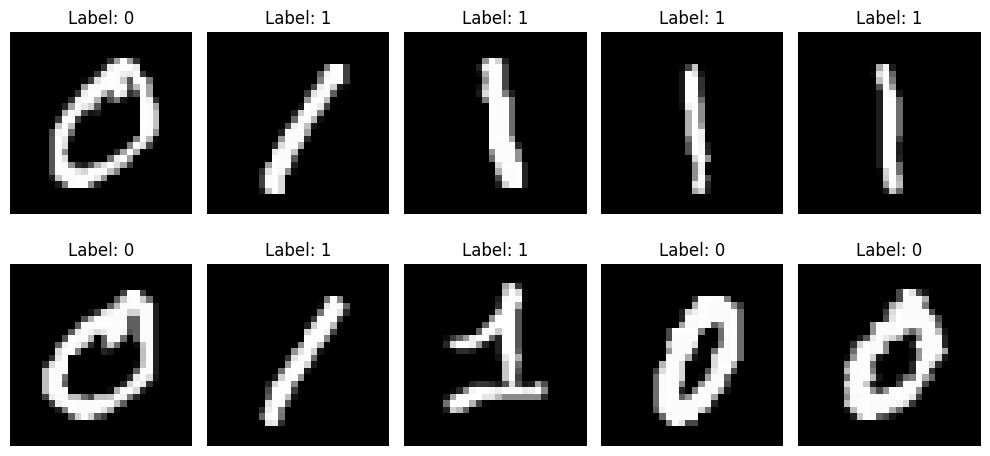

In [9]:
fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        train_images[i].squeeze(),
        cmap='gray'
    )

    ax.set_title(
        f"Label: {train_labels[i]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

Flatten Images

In [10]:
X_train = np.array(
    [img.view(-1).numpy() for img in train_images]
)

X_test = np.array(
    [img.view(-1).numpy() for img in test_images]
)

y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(X_train.shape)
print(X_test.shape)

(2000, 784)
(500, 784)


PCA Reduction

For the initial 4-qubit experiment:

In [11]:
pca = PCA(
    n_components=4,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(X_train_pca.shape)
print(X_test_pca.shape)

(2000, 4)
(500, 4)


Variance Retained

In [12]:
# Section 10: Variance Retained Analysis

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance retained:")
print(np.sum(pca.explained_variance_ratio_))

Explained variance ratio:
[0.33417928 0.09182893 0.08226233 0.05230507]

Total variance retained:
0.5605756


In [13]:
# Variance explained by each principal component

for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print("\nTotal Variance Retained: "
      f"{np.sum(pca.explained_variance_ratio_)*100:.2f}%")

PC1: 0.3342 (33.42%)
PC2: 0.0918 (9.18%)
PC3: 0.0823 (8.23%)
PC4: 0.0523 (5.23%)

Total Variance Retained: 56.06%


In [14]:
# Cumulative variance

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print("Cumulative Variance:")
print(cumulative_variance)

Cumulative Variance:
[0.33417928 0.42600822 0.50827056 0.5605756 ]


PCA Visualization

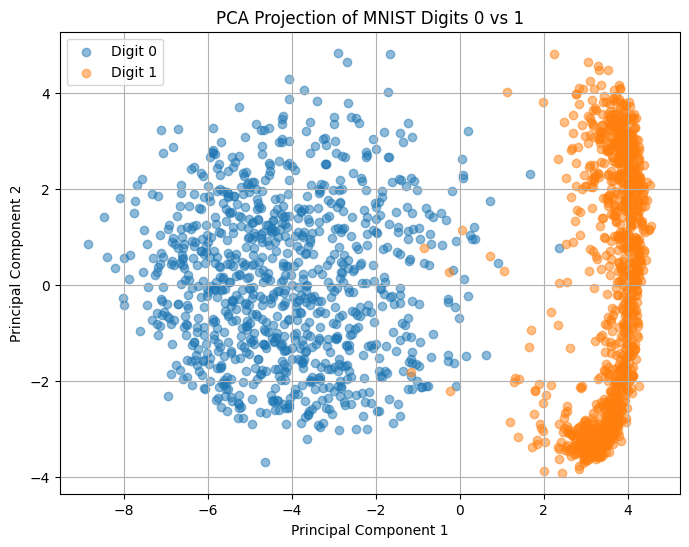

In [15]:
# Section 11: PCA Scatter Plot Visualization

plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[y_train == 0, 0],
    X_train_pca[y_train == 0, 1],
    alpha=0.5,
    label='Digit 0'
)

plt.scatter(
    X_train_pca[y_train == 1, 0],
    X_train_pca[y_train == 1, 1],
    alpha=0.5,
    label='Digit 1'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection of MNIST Digits 0 vs 1")

plt.legend()
plt.grid(True)

plt.show()

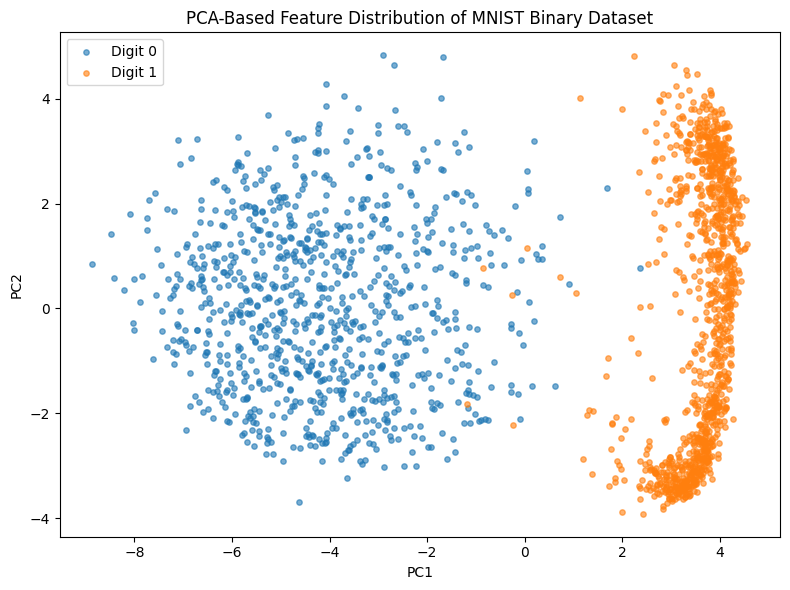

In [16]:
# Publication-quality PCA visualization

plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[y_train == 0, 0],
    X_train_pca[y_train == 0, 1],
    s=15,
    alpha=0.6,
    label='Digit 0'
)

plt.scatter(
    X_train_pca[y_train == 1, 0],
    X_train_pca[y_train == 1, 1],
    s=15,
    alpha=0.6,
    label='Digit 1'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA-Based Feature Distribution of MNIST Binary Dataset")
plt.legend()
plt.tight_layout()

plt.savefig(
    "PCA_MNIST_0_vs_1.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

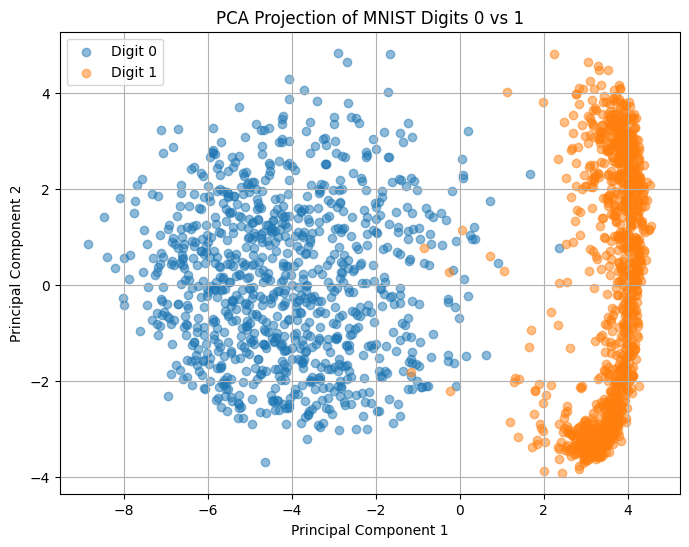

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[y_train==0,0],
    X_train_pca[y_train==0,1],
    alpha=0.5,
    label='Digit 0'
)

plt.scatter(
    X_train_pca[y_train==1,0],
    X_train_pca[y_train==1,1],
    alpha=0.5,
    label='Digit 1'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of MNIST Digits 0 vs 1")

plt.legend()
plt.grid(True)

plt.savefig(
    "Fig_E1_PCA_Scatter_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
from google.colab import files

files.download("Fig_E1_PCA_Scatter_Plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import numpy as np

np.save("X_train_pca.npy", X_train_pca)
np.save("X_test_pca.npy", X_test_pca)

np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

print("Files saved successfully.")

Files saved successfully.


In [18]:
from google.colab import files

files.download('X_train_pca.npy')
files.download('X_test_pca.npy')
files.download('y_train.npy')
files.download('y_test.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Experiment E1: Dataset Preparation and Feature Reduction
Configuration

Dataset: MNIST
Classes: 0 and 1
Training Samples: 2000
Testing Samples: 500
Original Dimension: 784
PCA Components: 4

Results

Explained Variance Ratio:
PC1 = 33.42%
PC2 = 9.18%
PC3 = 8.23%
PC4 = 5.23%

Total Variance Retained:
56.06%